# Step-by-step inspection for `CascadingMitigationEnv`

这个 notebook 用于**小网络分步检测**新的 mitigation environment 是否符合设计：

- 初始失效是否先由环境触发；
- action mask 是否合理；
- `protect node` 是否生效；
- `disconnect edge` 是否会改变拓扑；
- `do nothing` 是否正常；
- 每一步后网络形态、失败节点、保护节点、断开边、负载比例是否符合预期。

建议把这个 notebook 放到：

```text
cascading_mitigation_project/notebooks/inspect_mitigation_env_step_by_step.ipynb
```

然后从项目根目录启动：

```powershell
cd cascading_mitigation_project
jupyter notebook notebooks/inspect_mitigation_env_step_by_step.ipynb
```

In [30]:
# Cell 1: imports and path setup

from pathlib import Path
import sys
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# Make imports work whether the notebook is opened from project root or notebooks/.
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from envs.cascading_mitigation_env import CascadingMitigationEnv
from envs.actions import action_to_string

print("Project root:", PROJECT_ROOT)

Project root: d:\26_06\0622_fyp


In [46]:
# Cell 2: create a small environment

env = CascadingMitigationEnv(
    N=20,
    network_type="BA",
    
    m=2,
    alpha=0.15,
    max_steps=6,
    budget=3.0,
    protect_cost=1.0,
    disconnect_cost=1.0,
    protect_strength=0.8,
    protect_duration=2,
    failure_model="deterministic",
    redistribution_mode="uniform",
    load_type="degree",
    initial_failures=1,
    initial_failure_strategy="highest_load",
    allow_disconnect=True,
    seed=7,
)

obs, info = env.reset()

print("Initial info:")
for k, v in info.items():
    print(f"{k}: {v}")

print("\nAction dimension:", env.action_dim)
print("Do-nothing action id:", env.do_nothing_action_id)
print("Valid action ids:", np.where(obs["action_mask"] == 1)[0])

Initial info:
step: 0
initial_failed_nodes: [3]
budget_left: 3.0
damage: 0.2750000000000001
failed_fraction: 0.05
lcc_ratio: 0.95
lost_load_ratio: 0.125
served_load_ratio: 0.875
budget_used: 0.0

Action dimension: 57
Do-nothing action id: 56
Valid action ids: [ 0  1  2  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 23 24 25
 26 27 29 30 31 32 33 34 35 36 44 45 46 47 48 49 50 51 52 53 54 55 56]


In [48]:
# Cell 3: helper functions for inspection and visualization

def summarize_obs(obs, info=None):
    """Print compact state information."""
    failed = np.where(obs["failed_mask"] == 1)[0]
    protected = np.where(obs["protected_mask"] == 1)[0]
    valid_actions = np.where(obs["action_mask"] == 1)[0]

    print("Failed nodes:", failed.tolist())
    print("Protected nodes:", protected.tolist())
    print("Budget left:", float(obs["global_features"][1] * env.initial_budget))
    print("Valid actions:", valid_actions.tolist())

    print("\nNode table:")
    print("node | load | capacity | load/cap | failed | protected")
    for i in range(env.N):
        print(
            f"{i:>4} | "
            f"{obs['node_load'][i]:>6.3f} | "
            f"{obs['node_capacity'][i]:>8.3f} | "
            f"{obs['load_ratio'][i]:>8.3f} | "
            f"{int(obs['failed_mask'][i]):>6} | "
            f"{int(obs['protected_mask'][i]):>9}"
        )

    if info is not None:
        print("\nInfo:")
        for k, v in info.items():
            print(f"{k}: {v}")


def get_node_style(obs):
    labels = {}
    node_colors = []
    border_colors = []
    node_sizes = []

    for i in range(env.N):
        load_ratio = float(obs["load_ratio"][i])
        labels[i] = f"{i}\n{load_ratio:.2f}"

        if obs["failed_mask"][i] == 1:
            node_colors.append("lightgray")
            border_colors.append("black")
            node_sizes.append(900)
        elif obs["protected_mask"][i] == 1:
            node_colors.append("lightgreen")
            border_colors.append("black")
            node_sizes.append(950)
        else:
            node_colors.append("lightskyblue")
            border_colors.append("black")
            node_sizes.append(850)

    return labels, node_colors, border_colors, node_sizes


# Fixed layout based on the original graph, so topology changes are visually comparable across steps.
BASE_GRAPH = nx.from_numpy_array(env.base_adj)
POS = nx.spring_layout(BASE_GRAPH, seed=123)


def visualize_env(obs, title="Network state"):
    """
    Node label:
        node_id
        load/capacity ratio

    Colors:
        blue  = active normal node
        green = protected node
        gray  = failed node

    Edges:
        solid edge       = active edge
        dashed faint edge = inactive edge from original graph
    """
    active_graph = nx.from_numpy_array(obs["adj_matrix"])
    original_graph = nx.from_numpy_array(env.base_adj)

    labels, node_colors, border_colors, node_sizes = get_node_style(obs)

    plt.figure(figsize=(8, 6))
    plt.title(title)

    inactive_edges = []
    active_edges = set(tuple(sorted(e)) for e in active_graph.edges())
    for e in original_graph.edges():
        e_sorted = tuple(sorted(e))
        if e_sorted not in active_edges:
            inactive_edges.append(e)

    nx.draw_networkx_edges(
        original_graph,
        POS,
        edgelist=inactive_edges,
        style="dashed",
        alpha=0.25,
        width=1.0,
    )

    nx.draw_networkx_edges(
        active_graph,
        POS,
        edgelist=list(active_graph.edges()),
        width=2.0,
    )

    nx.draw_networkx_nodes(
        original_graph,
        POS,
        node_color=node_colors,
        edgecolors=border_colors,
        node_size=node_sizes,
        linewidths=1.5,
    )

    nx.draw_networkx_labels(
        original_graph,
        POS,
        labels=labels,
        font_size=9,
    )

    plt.axis("off")
    plt.show()


In [49]:
print("Do-nothing action id:", env.do_nothing_action_id)
print("Valid action ids:", np.where(obs["action_mask"] == 1)[0])

Do-nothing action id: 56
Valid action ids: [ 0  1  2  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 23 24 25
 26 27 29 30 31 32 33 34 35 36 44 45 46 47 48 49 50 51 52 53 54 55 56]


In [50]:
# list all valid actions in readable form

valid_actions = np.where(obs["action_mask"] == 1)[0]

print("Readable valid actions:")
for a in valid_actions:
    print(f"{a:>3}: {action_to_string(int(a), env.N, env.edge_list)}")

Readable valid actions:
  0: protect_node(0)
  1: protect_node(1)
  2: protect_node(2)
  4: protect_node(4)
  5: protect_node(5)
  6: protect_node(6)
  7: protect_node(7)
  8: protect_node(8)
  9: protect_node(9)
 10: protect_node(10)
 11: protect_node(11)
 12: protect_node(12)
 13: protect_node(13)
 14: protect_node(14)
 15: protect_node(15)
 16: protect_node(16)
 17: protect_node(17)
 18: protect_node(18)
 19: protect_node(19)
 20: disconnect_edge(0: 0-1)
 21: disconnect_edge(1: 0-2)
 23: disconnect_edge(3: 0-4)
 24: disconnect_edge(4: 0-5)
 25: disconnect_edge(5: 0-6)
 26: disconnect_edge(6: 0-7)
 27: disconnect_edge(7: 0-17)
 29: disconnect_edge(9: 1-5)
 30: disconnect_edge(10: 1-7)
 31: disconnect_edge(11: 1-8)
 32: disconnect_edge(12: 1-9)
 33: disconnect_edge(13: 1-15)
 34: disconnect_edge(14: 2-10)
 35: disconnect_edge(15: 2-12)
 36: disconnect_edge(16: 2-14)
 44: disconnect_edge(24: 5-11)
 45: disconnect_edge(25: 5-12)
 46: disconnect_edge(26: 5-13)
 47: disconnect_edge(27: 5-

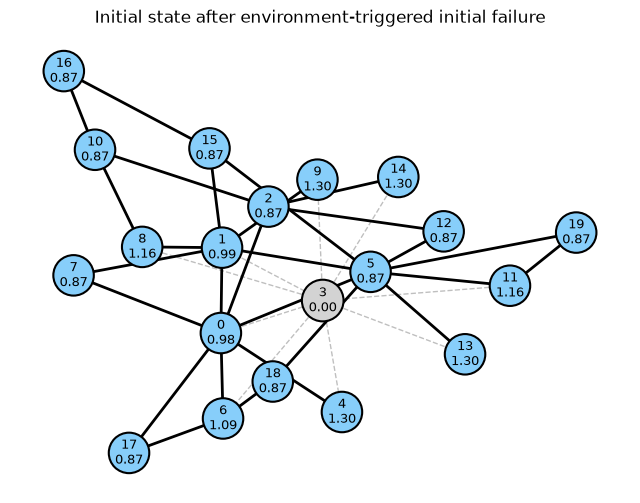

In [51]:
visualize_env(obs, title="Initial state after environment-triggered initial failure")

Failed nodes: [3]
Protected nodes: []
Budget left: 3.0
Valid actions: [0, 1, 2, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 23, 24, 25, 26, 27, 29, 30, 31, 32, 33, 34, 35, 36, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56]

Node table:
node | load | capacity | load/cap | failed | protected
   0 |  9.000 |    9.200 |    0.978 |      0 |         0
   1 |  8.000 |    8.050 |    0.994 |      0 |         0
   2 |  4.000 |    4.600 |    0.870 |      0 |         0
   3 |  0.000 |   10.350 |    0.000 |      1 |         0
   4 |  3.000 |    2.300 |    1.304 |      0 |         0
   5 |  8.000 |    9.200 |    0.870 |      0 |         0
   6 |  5.000 |    4.600 |    1.087 |      0 |         0
   7 |  2.000 |    2.300 |    0.870 |      0 |         0
   8 |  4.000 |    3.450 |    1.159 |      0 |         0
   9 |  3.000 |    2.300 |    1.304 |      0 |         0
  10 |  3.000 |    3.450 |    0.870 |      0 |         0
  11 |  4.000 |    3.450 |    1.159 |      0 |         

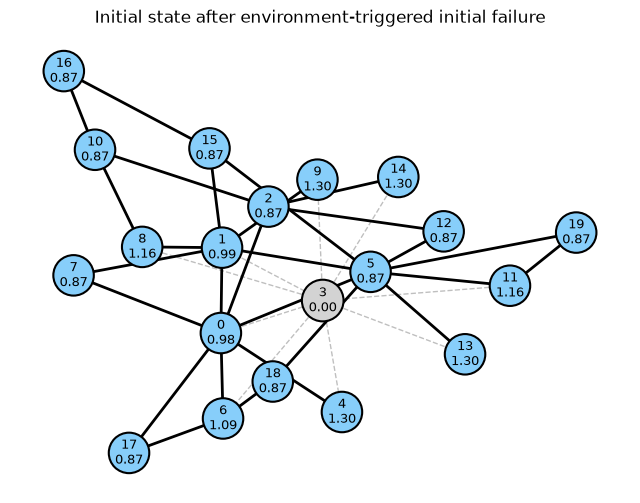

In [52]:
summarize_obs(obs, info)
visualize_env(obs, title="Initial state after environment-triggered initial failure")

Chosen action: 4 protect_node(4)

Reward: -1.222222222222222
Terminated: False Truncated: False
Failed nodes: [3, 6, 8, 9, 11, 13, 14]
Protected nodes: [4]
Budget left: 2.0
Valid actions: [0, 1, 2, 5, 7, 10, 12, 15, 16, 17, 18, 19, 20, 21, 23, 24, 26, 27, 29, 30, 33, 34, 35, 45, 47, 48, 49, 53, 55, 56]

Node table:
node | load | capacity | load/cap | failed | protected
   0 | 10.667 |    9.200 |    1.159 |      0 |         0
   1 | 13.000 |    8.050 |    1.615 |      0 |         0
   2 |  7.000 |    4.600 |    1.522 |      0 |         0
   3 |  0.000 |   10.350 |    0.000 |      1 |         0
   4 |  3.000 |    2.300 |    1.304 |      0 |         1
   5 | 13.000 |    9.200 |    1.413 |      0 |         0
   6 |  0.000 |    4.600 |    0.000 |      1 |         0
   7 |  2.000 |    2.300 |    0.870 |      0 |         0
   8 |  0.000 |    3.450 |    0.000 |      1 |         0
   9 |  0.000 |    2.300 |    0.000 |      1 |         0
  10 |  5.000 |    3.450 |    1.449 |      0 |         0
 

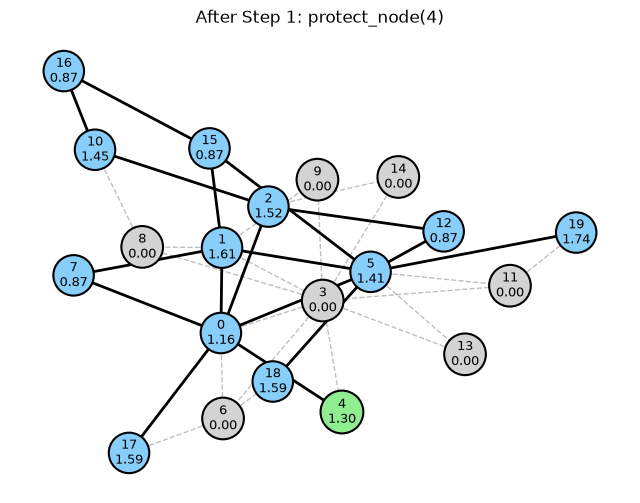

In [53]:
# Cell 5: Step 1 — choose a protection action manually

# Strategy for inspection:
# protect the valid active node with the highest load/capacity ratio.
valid_actions = np.where(obs["action_mask"] == 1)[0]
valid_node_actions = [a for a in valid_actions if a < env.N]

if len(valid_node_actions) > 0:
    load_ratio = obs["load_ratio"]
    action = int(max(valid_node_actions, key=lambda a: load_ratio[a]))
else:
    action = env.do_nothing_action_id

print("Chosen action:", action, action_to_string(action, env.N, env.edge_list))

obs, reward, terminated, truncated, info = env.step(action)

print("\nReward:", reward)
print("Terminated:", terminated, "Truncated:", truncated)
summarize_obs(obs, info)
visualize_env(obs, title=f"After Step 1: {action_to_string(action, env.N, env.edge_list)}")

Chosen action: 20 disconnect_edge(0: 0-1)

Reward: -2.1
Terminated: False Truncated: False
Failed nodes: [0, 1, 2, 3, 5, 6, 8, 9, 10, 11, 13, 14, 17, 18, 19]
Protected nodes: []
Budget left: 1.0
Valid actions: [4, 7, 12, 15, 16, 55, 56]

Node table:
node | load | capacity | load/cap | failed | protected
   0 |  0.000 |    9.200 |    0.000 |      1 |         0
   1 |  0.000 |    8.050 |    0.000 |      1 |         0
   2 |  0.000 |    4.600 |    0.000 |      1 |         0
   3 |  0.000 |   10.350 |    0.000 |      1 |         0
   4 |  8.333 |    2.300 |    3.623 |      0 |         0
   5 |  0.000 |    9.200 |    0.000 |      1 |         0
   6 |  0.000 |    4.600 |    0.000 |      1 |         0
   7 | 13.833 |    2.300 |    6.014 |      0 |         0
   8 |  0.000 |    3.450 |    0.000 |      1 |         0
   9 |  0.000 |    2.300 |    0.000 |      1 |         0
  10 |  0.000 |    3.450 |    0.000 |      1 |         0
  11 |  0.000 |    3.450 |    0.000 |      1 |         0
  12 | 15.5

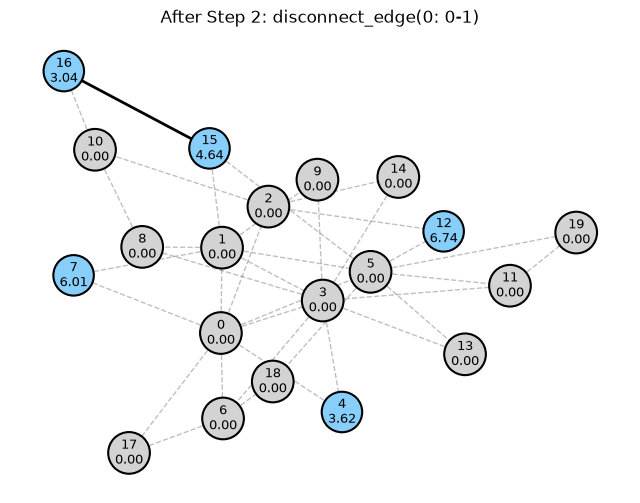

In [54]:
# Cell 6: Step 2 — choose a valid edge disconnection action

def choose_first_valid_disconnect_action(obs):
    valid_actions = np.where(obs["action_mask"] == 1)[0]
    edge_actions = [a for a in valid_actions if env.N <= a < env.N + env.num_edges]
    if len(edge_actions) == 0:
        return env.do_nothing_action_id
    return int(edge_actions[0])


if not (terminated or truncated):
    action = choose_first_valid_disconnect_action(obs)
    print("Chosen action:", action, action_to_string(action, env.N, env.edge_list))

    obs, reward, terminated, truncated, info = env.step(action)

    print("\nReward:", reward)
    print("Terminated:", terminated, "Truncated:", truncated)
    summarize_obs(obs, info)
    visualize_env(obs, title=f"After Step 2: {action_to_string(action, env.N, env.edge_list)}")
else:
    print("Episode already ended before Step 2.")

Chosen action: 56 do_nothing

Reward: -0.6027777777777779
Terminated: True Truncated: False
Failed nodes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
Protected nodes: []
Budget left: 1.0
Valid actions: [56]

Node table:
node | load | capacity | load/cap | failed | protected
   0 |  0.000 |    9.200 |    0.000 |      1 |         0
   1 |  0.000 |    8.050 |    0.000 |      1 |         0
   2 |  0.000 |    4.600 |    0.000 |      1 |         0
   3 |  0.000 |   10.350 |    0.000 |      1 |         0
   4 |  0.000 |    2.300 |    0.000 |      1 |         0
   5 |  0.000 |    9.200 |    0.000 |      1 |         0
   6 |  0.000 |    4.600 |    0.000 |      1 |         0
   7 |  0.000 |    2.300 |    0.000 |      1 |         0
   8 |  0.000 |    3.450 |    0.000 |      1 |         0
   9 |  0.000 |    2.300 |    0.000 |      1 |         0
  10 |  0.000 |    3.450 |    0.000 |      1 |         0
  11 |  0.000 |    3.450 |    0.000 |      1 |         0
  12 |  0.000 

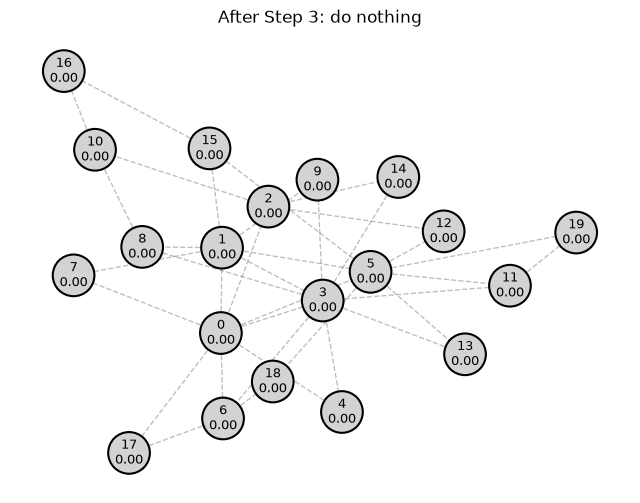

In [55]:
# Cell 7: Step 3 — choose do-nothing

if not (terminated or truncated):
    action = env.do_nothing_action_id
    print("Chosen action:", action, action_to_string(action, env.N, env.edge_list))

    obs, reward, terminated, truncated, info = env.step(action)

    print("\nReward:", reward)
    print("Terminated:", terminated, "Truncated:", truncated)
    summarize_obs(obs, info)
    visualize_env(obs, title="After Step 3: do nothing")
else:
    print("Episode already ended before Step 3.")

In [56]:
# Cell 8: Continue with random valid actions until the episode ends

history = []

while not (terminated or truncated):
    valid_actions = np.where(obs["action_mask"] == 1)[0]
    action = int(np.random.choice(valid_actions))

    obs, reward, terminated, truncated, info = env.step(action)

    record = {
        "step": info["step"],
        "action": action_to_string(action, env.N, env.edge_list),
        "reward": reward,
        "damage": info["damage"],
        "failed_fraction": info["failed_fraction"],
        "lcc_ratio": info["lcc_ratio"],
        "lost_load_ratio": info["lost_load_ratio"],
        "budget_left": info["budget_left"],
    }
    history.append(record)

    print("\n" + "=" * 80)
    print("Step:", record["step"])
    print("Action:", record["action"])
    print("Reward:", record["reward"])
    print("Damage:", record["damage"])
    print("Failed fraction:", record["failed_fraction"])
    print("LCC ratio:", record["lcc_ratio"])
    print("Lost load ratio:", record["lost_load_ratio"])
    print("Budget left:", record["budget_left"])

    visualize_env(obs, title=f"After Step {record['step']}: {record['action']}")

print("\nEpisode ended.")
print("Final info:", info)


Episode ended.
Final info: {'step': 3, 'initial_failed_nodes': [3], 'budget_left': 1.0, 'damage': 4.0, 'failed_fraction': 1.0, 'lcc_ratio': 0.0, 'lost_load_ratio': 1.0, 'served_load_ratio': 0.0, 'budget_used': 2.0, 'action_id': 56, 'action_name': 'do_nothing', 'action_type': 'do_nothing', 'target': None, 'cost': 0.0, 'invalid': False, 'new_failed_nodes': [4, 7, 12, 15, 16], 'previous_damage': 3.397222222222222, 'current_damage': 4.0}
